# 1. Project Overview

This notebook rebuilds churn prediction from the processed datasets in `data/processed/`. The previous churn notebook is treated only as a reference artifact; all target logic, features, visualizations, models, and recommendations are derived from the available processed files.

The processed layer contains customer records, transaction behavior, and monthly aggregate metrics. The customer dataset is the modeling grain because it contains one row per customer and includes observed churn.

# 2. Import Libraries

The workflow uses production-oriented Python utilities, `pandas`/`numpy` for data work, `matplotlib` and `seaborn` for every visualization, and `scikit-learn` for modeling. XGBoost and SHAP are loaded only when installed.

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier

    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    import shap

    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE

    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

# 3. Configuration

All paths, random seeds, logging settings, and risk thresholds are centralized here. Figures are written to `outputs/figures/`; predictions, model metrics, and customer reports are written to `outputs/`.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.25
TARGET_COLUMN = "churn_target"
CUSTOMER_ID_COLUMN = "customer_id"
HIGH_RISK_THRESHOLD = 0.65
MEDIUM_RISK_THRESHOLD = 0.35

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger("churn_prediction")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

# 4. Load Processed Data

Every cleaned CSV under `data/processed/` is discovered and loaded. The customer table becomes the primary modeling dataset; transactions and monthly metrics remain available for behavior features and churn context.

In [3]:
def load_processed_csvs(data_dir: Path) -> Dict[str, pd.DataFrame]:
    """Load all processed CSV files with explicit error handling."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Processed data directory not found: {data_dir}")

    csv_paths = sorted(data_dir.glob("*.csv"))
    if not csv_paths:
        raise FileNotFoundError(f"No processed CSV files found in: {data_dir}")

    datasets: Dict[str, pd.DataFrame] = {}
    for path in csv_paths:
        try:
            datasets[path.name] = pd.read_csv(path)
            logger.info("Loaded %s with shape %s", path.name, datasets[path.name].shape)
        except Exception as exc:
            logger.exception("Failed to load %s", path.name)
            raise RuntimeError(f"Unable to load {path.name}") from exc
    return datasets


def find_dataset(
    datasets: Dict[str, pd.DataFrame],
    required_columns: Iterable[str],
    preferred_name: Optional[str] = None,
) -> Optional[pd.DataFrame]:
    """Return a dataset containing the required columns."""
    required = set(required_columns)
    if preferred_name in datasets and required.issubset(datasets[preferred_name].columns):
        return datasets[preferred_name].copy()

    for data in datasets.values():
        if required.issubset(data.columns):
            return data.copy()
    return None


def build_dataset_inventory(datasets: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Create an inventory of loaded datasets."""
    records = []
    for name, data in datasets.items():
        records.append(
            {
                "dataset": name,
                "rows": data.shape[0],
                "columns": data.shape[1],
                "missing_values": int(data.isna().sum().sum()),
                "duplicate_rows": int(data.duplicated().sum()),
            }
        )
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)


processed_data = load_processed_csvs(DATA_DIR)
customers_raw = find_dataset(
    processed_data,
    required_columns=[CUSTOMER_ID_COLUMN],
    preferred_name="financial_customers_clean.csv",
)
transactions_raw = find_dataset(
    processed_data,
    required_columns=[CUSTOMER_ID_COLUMN, "transaction_date"],
    preferred_name="financial_transactions_clean.csv",
)
monthly_raw = find_dataset(
    processed_data,
    required_columns=["year_month"],
    preferred_name="monthly_revenue_clean.csv",
)

if customers_raw is None:
    raise ValueError("No customer-level dataset with customer_id was found.")

display(build_dataset_inventory(processed_data))

2026-07-08 21:20:33,024 - INFO - Loaded financial_customers_clean.csv with shape (20000, 36)
2026-07-08 21:20:33,886 - INFO - Loaded financial_transactions_clean.csv with shape (329202, 30)
2026-07-08 21:20:33,891 - INFO - Loaded monthly_revenue_clean.csv with shape (36, 18)


,dataset,rows,columns,missing_values,duplicate_rows
0,financial_customers_clean.csv,20000,36,0,0
1,financial_transactions_clean.csv,329202,30,0,0
2,monthly_revenue_clean.csv,36,18,0,0


# 5. Business Problem

The business objective is to predict which customers are likely to churn, identify the strongest risk signals, and export a prioritized high-risk customer list for retention action. The model output is a customer-level churn probability that is converted into operational risk bands.

# 6. Churn Target Preparation

The customer dataset already contains a binary `churn` column, so the notebook uses that observed churn target directly: `1 = churned`, `0 = retained`.

If a future dataset does not contain an explicit churn field, the fallback rule is defined but not used here: first use active/cancellation status when available; otherwise use inactivity from transaction recency; otherwise use adverse subscription or payment behavior such as failed, refunded, or downgrade-heavy activity. Direct target encoders such as `is_active` are excluded from model features to prevent leakage.

In [4]:
def normalize_binary_target(series: pd.Series) -> pd.Series:
    """Normalize common binary target representations to 0/1 integers."""
    if pd.api.types.is_numeric_dtype(series):
        numeric = series.astype(float)
        if set(numeric.dropna().unique()).issubset({0.0, 1.0}):
            return numeric.astype(int)

    mapping = {
        "yes": 1,
        "y": 1,
        "true": 1,
        "1": 1,
        "churned": 1,
        "inactive": 1,
        "cancelled": 1,
        "canceled": 1,
        "closed": 1,
        "no": 0,
        "n": 0,
        "false": 0,
        "0": 0,
        "retained": 0,
        "active": 0,
        "current": 0,
    }
    normalized = series.astype(str).str.strip().str.lower().map(mapping)
    if normalized.notna().all() and normalized.nunique() == 2:
        return normalized.astype(int)
    raise ValueError("Target column cannot be converted to binary churn.")


def find_existing_churn_column(data: pd.DataFrame) -> Optional[str]:
    """Find an explicit churn field from the available dataset columns."""
    churn_names = {
        "churn",
        "churned",
        "is_churned",
        "churn_flag",
        "customer_churn",
        "has_churned",
    }
    for column in data.columns:
        normalized = column.strip().lower().replace(" ", "_")
        if normalized in churn_names:
            try:
                normalize_binary_target(data[column])
                return column
            except ValueError:
                logger.warning("Column %s looked like churn but was not binary.", column)
    return None


def derive_churn_from_business_rules(
    customers: pd.DataFrame,
    transactions: Optional[pd.DataFrame],
) -> Tuple[pd.Series, Dict[str, Any]]:
    """Derive churn only when no explicit target is available."""
    audit: Dict[str, Any] = {"target_source": "derived_business_rule"}

    status_columns = [
        column
        for column in customers.columns
        if any(token in column.lower() for token in ["active", "status", "cancel"])
    ]
    for column in status_columns:
        values = customers[column]
        if pd.api.types.is_numeric_dtype(values):
            unique_values = set(values.dropna().unique())
            if unique_values.issubset({0, 1}):
                audit["rule"] = f"Derived from numeric status column: {column}"
                if "active" in column.lower():
                    return (1 - values.astype(int)), audit
                return values.astype(int), audit

        lower_values = values.astype(str).str.lower().str.strip()
        churn_terms = lower_values.isin(["inactive", "cancelled", "canceled", "closed"])
        active_terms = lower_values.isin(["active", "current", "open"])
        if (churn_terms | active_terms).all() and churn_terms.any():
            audit["rule"] = f"Derived from categorical status column: {column}"
            return churn_terms.astype(int), audit

    if "days_since_last_transaction" in customers.columns:
        recency = pd.to_numeric(customers["days_since_last_transaction"], errors="coerce")
        threshold = max(90, int(recency.quantile(0.75)))
        audit["rule"] = "Derived from inactivity using days_since_last_transaction"
        audit["inactivity_threshold_days"] = threshold
        return (recency > threshold).fillna(False).astype(int), audit

    if transactions is not None and {CUSTOMER_ID_COLUMN, "transaction_date"}.issubset(transactions.columns):
        transaction_dates = pd.to_datetime(transactions["transaction_date"], errors="coerce")
        analysis_date = transaction_dates.max() + pd.Timedelta(days=1)
        last_seen = transactions.assign(transaction_date=transaction_dates).groupby(CUSTOMER_ID_COLUMN)[
            "transaction_date"
        ].max()
        recency = customers[CUSTOMER_ID_COLUMN].map((analysis_date - last_seen).dt.days)
        threshold = max(90, int(recency.quantile(0.75)))
        audit["rule"] = "Derived from transaction inactivity"
        audit["inactivity_threshold_days"] = threshold
        return (recency > threshold).fillna(True).astype(int), audit

    raise ValueError("No explicit churn target or defensible fallback churn rule is available.")


def prepare_churn_target(
    customers: pd.DataFrame,
    transactions: Optional[pd.DataFrame],
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Attach the modeling churn target and document its source."""
    data = customers.copy()
    churn_column = find_existing_churn_column(data)

    if churn_column is not None:
        data[TARGET_COLUMN] = normalize_binary_target(data[churn_column])
        audit = {
            "target_source": "existing_dataset_column",
            "source_column": churn_column,
            "logic": "Observed binary churn field found in processed customer dataset.",
        }
    else:
        data[TARGET_COLUMN], audit = derive_churn_from_business_rules(data, transactions)
        audit["source_column"] = TARGET_COLUMN

    audit["rows"] = len(data)
    audit["churned_customers"] = int(data[TARGET_COLUMN].sum())
    audit["retained_customers"] = int((1 - data[TARGET_COLUMN]).sum())
    audit["churn_rate"] = float(data[TARGET_COLUMN].mean())
    return data, audit


customers, target_audit = prepare_churn_target(customers_raw, transactions_raw)
display(pd.DataFrame([target_audit]))

if "is_active" in customers.columns:
    display(pd.crosstab(customers["is_active"], customers[TARGET_COLUMN], margins=True))

,target_source,source_column,logic,rows,churned_customers,retained_customers,churn_rate
0,existing_dataset_column,churn,Observed binary churn field found in processed...,20000,5560,14440,0.2780


churn_target,0,1,All
is_active,,,
0,0,5560,5560
1,14440,0,14440
All,14440,5560,20000


# 7. Dataset Overview

This section reviews dataset shapes, field types, missingness, duplicate customer identifiers, and target balance before modeling.

In [5]:
def summarize_columns(data: pd.DataFrame) -> pd.DataFrame:
    """Summarize type, missingness, and cardinality by column."""
    return pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing_count": data.isna().sum(),
            "missing_rate": data.isna().mean(),
            "unique_values": data.nunique(dropna=True),
        }
    ).sort_values(["missing_rate", "unique_values"], ascending=[False, False])


overview_records = []
for name, data in processed_data.items():
    overview_records.append(
        {
            "dataset": name,
            "rows": data.shape[0],
            "columns": data.shape[1],
            "numeric_columns": data.select_dtypes(include=np.number).shape[1],
            "categorical_columns": data.select_dtypes(exclude=np.number).shape[1],
            "missing_cells": int(data.isna().sum().sum()),
        }
    )

display(pd.DataFrame(overview_records).sort_values("dataset"))
display(summarize_columns(customers).head(20))

if CUSTOMER_ID_COLUMN in customers.columns:
    duplicate_customers = int(customers[CUSTOMER_ID_COLUMN].duplicated().sum())
    print(f"Duplicate customer_id rows: {duplicate_customers}")

print(
    "Churn rate: "
    f"{customers[TARGET_COLUMN].mean():.2%} "
    f"({customers[TARGET_COLUMN].sum():,.0f} of {len(customers):,.0f} customers)"
)

,dataset,rows,columns,numeric_columns,categorical_columns,missing_cells
0,financial_customers_clean.csv,20000,36,21,15,0
1,financial_transactions_clean.csv,329202,30,17,13,0
2,monthly_revenue_clean.csv,36,18,15,3,0


,dtype,missing_count,missing_rate,unique_values
customer_id,object,0,0.0000,20000
total_revenue,float64,0,0.0000,19787
total_profit,float64,0,0.0000,19745
customer_lifetime_value,float64,0,0.0000,18677
customer_acquisition_cost,float64,0,0.0000,18214
average_transaction_value,float64,0,0.0000,17148
monthly_recurring_revenue,float64,0,0.0000,15697
city,object,0,0.0000,13249
signup_date,object,0,0.0000,1060
usage_score,float64,0,0.0000,902


Duplicate customer_id rows: 0
Churn rate: 27.80% (5,560 of 20,000 customers)


# 8. Churn Exploratory Analysis

The following visuals analyze churn using customer, transaction, and monthly aggregate data. Every chart is saved to `outputs/figures/` and followed by a business insight.

In [6]:
business_insights: List[Dict[str, str]] = []


def add_business_insight(section: str, insight: str) -> None:
    """Store and print an insight from a chart or model result."""
    business_insights.append({"section": section, "insight": insight})
    logger.info("%s insight: %s", section, insight)
    print(f"Business insight - {section}: {insight}")


def aggregate_transaction_behavior(transactions: Optional[pd.DataFrame]) -> pd.DataFrame:
    """Aggregate transaction behavior to one row per customer."""
    if transactions is None or CUSTOMER_ID_COLUMN not in transactions.columns:
        return pd.DataFrame({CUSTOMER_ID_COLUMN: customers[CUSTOMER_ID_COLUMN]})

    data = transactions.copy()
    if "transaction_date" in data.columns:
        data["transaction_date"] = pd.to_datetime(data["transaction_date"], errors="coerce")

    if "transaction_status" in data.columns:
        status = data["transaction_status"].astype(str).str.lower()
        data["txn_completed_flag"] = status.eq("completed").astype(int)
        data["txn_failed_flag"] = status.eq("failed").astype(int)
        data["txn_refunded_flag"] = status.eq("refunded").astype(int)

    if "transaction_category" in data.columns:
        category = data["transaction_category"].astype(str).str.lower()
        data["txn_downgrade_flag"] = category.eq("downgrade").astype(int)
        data["txn_upgrade_flag"] = category.eq("upgrade").astype(int)
        data["txn_support_flag"] = category.eq("support").astype(int)

    aggregation_map = {
        "transaction_id": "count",
        "net_revenue": "sum",
        "profit": "sum",
        "gross_amount": "sum",
        "refund_amount": "sum",
        "payment_delay_days": "mean",
        "transaction_date": "max",
        "txn_completed_flag": "sum",
        "txn_failed_flag": "sum",
        "txn_refunded_flag": "sum",
        "txn_downgrade_flag": "sum",
        "txn_upgrade_flag": "sum",
        "txn_support_flag": "sum",
    }
    existing_map = {key: value for key, value in aggregation_map.items() if key in data.columns}
    aggregated = data.groupby(CUSTOMER_ID_COLUMN).agg(existing_map).reset_index()
    aggregated = aggregated.rename(
        columns={
            "transaction_id": "txn_count_from_transactions",
            "net_revenue": "txn_net_revenue_sum",
            "profit": "txn_profit_sum",
            "gross_amount": "txn_gross_amount_sum",
            "refund_amount": "txn_refund_amount_sum",
            "payment_delay_days": "txn_avg_payment_delay_days",
            "transaction_date": "txn_last_transaction_date",
            "txn_completed_flag": "txn_completed_count",
            "txn_failed_flag": "txn_failed_count",
            "txn_refunded_flag": "txn_refunded_count",
            "txn_downgrade_flag": "txn_downgrade_count",
            "txn_upgrade_flag": "txn_upgrade_count",
            "txn_support_flag": "txn_support_count",
        }
    )

    if "txn_count_from_transactions" in aggregated.columns:
        denominator = aggregated["txn_count_from_transactions"].replace(0, np.nan)
        for numerator, rate_column in [
            ("txn_failed_count", "txn_failed_rate"),
            ("txn_refunded_count", "txn_refunded_rate"),
            ("txn_downgrade_count", "txn_downgrade_rate"),
            ("txn_upgrade_count", "txn_upgrade_rate"),
            ("txn_support_count", "txn_support_rate"),
        ]:
            if numerator in aggregated.columns:
                aggregated[rate_column] = (aggregated[numerator] / denominator).fillna(0)
    return aggregated


transaction_behavior = aggregate_transaction_behavior(transactions_raw)
customers_with_txn = customers.merge(transaction_behavior, on=CUSTOMER_ID_COLUMN, how="left")

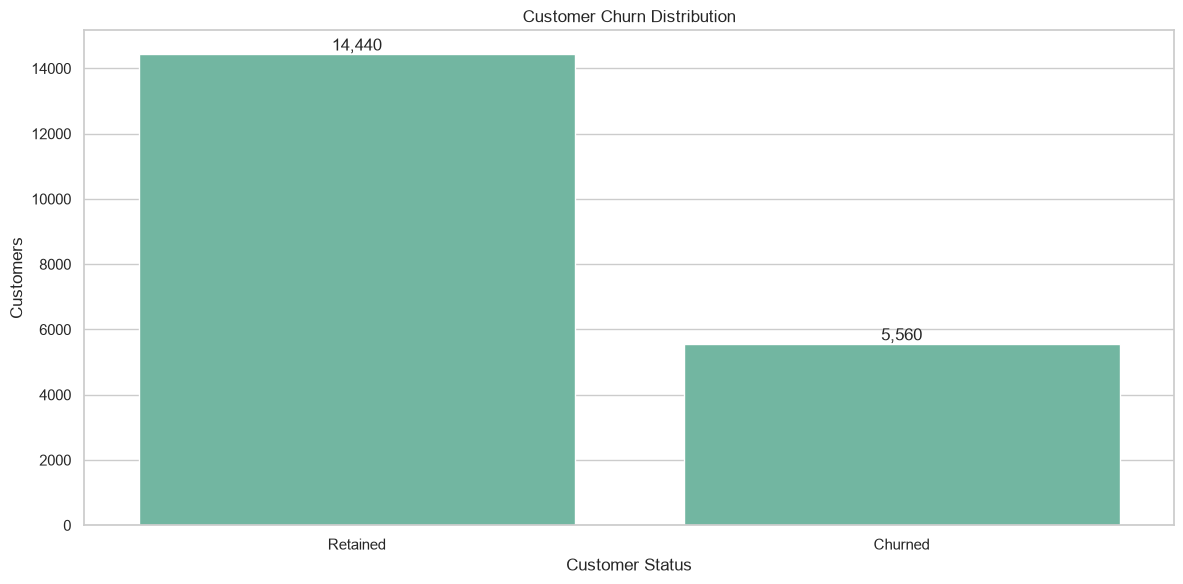

2026-07-08 21:20:35,079 - INFO - Churn Distribution insight: Observed churn is 27.8%, representing 5,560 customers.


Business insight - Churn Distribution: Observed churn is 27.8%, representing 5,560 customers.


In [7]:
churn_distribution = (
    customers[TARGET_COLUMN]
    .value_counts()
    .rename(index={0: "Retained", 1: "Churned"})
    .reset_index()
)
churn_distribution.columns = ["customer_status", "customers"]

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=churn_distribution, x="customer_status", y="customers", ax=ax)
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Customer Status")
ax.set_ylabel("Customers")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

add_business_insight(
    "Churn Distribution",
    f"Observed churn is {customers[TARGET_COLUMN].mean():.1%}, "
    f"representing {int(customers[TARGET_COLUMN].sum()):,} customers."
)

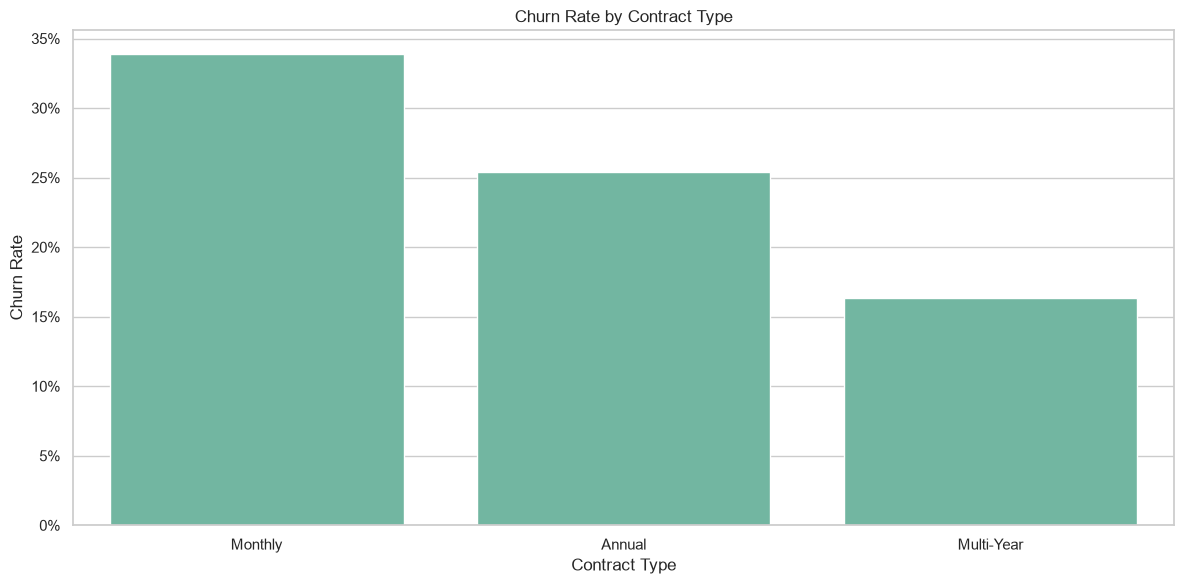

2026-07-08 21:20:35,240 - INFO - Contract Type insight: Monthly customers have the highest churn rate at 33.9%.


Business insight - Contract Type: Monthly customers have the highest churn rate at 33.9%.


In [8]:
if "contract_type" in customers.columns:
    contract_churn = (
        customers.groupby("contract_type", observed=False)[TARGET_COLUMN]
        .agg(churn_rate="mean", customers="size")
        .reset_index()
        .sort_values("churn_rate", ascending=False)
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=contract_churn, x="contract_type", y="churn_rate", ax=ax)
    ax.set_title("Churn Rate by Contract Type")
    ax.set_xlabel("Contract Type")
    ax.set_ylabel("Churn Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "churn_by_contract_type.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    top_contract = contract_churn.iloc[0]
    add_business_insight(
        "Contract Type",
        f"{top_contract['contract_type']} customers have the highest churn rate "
        f"at {top_contract['churn_rate']:.1%}."
    )
else:
    logger.info("contract_type column not available; skipped contract churn chart.")

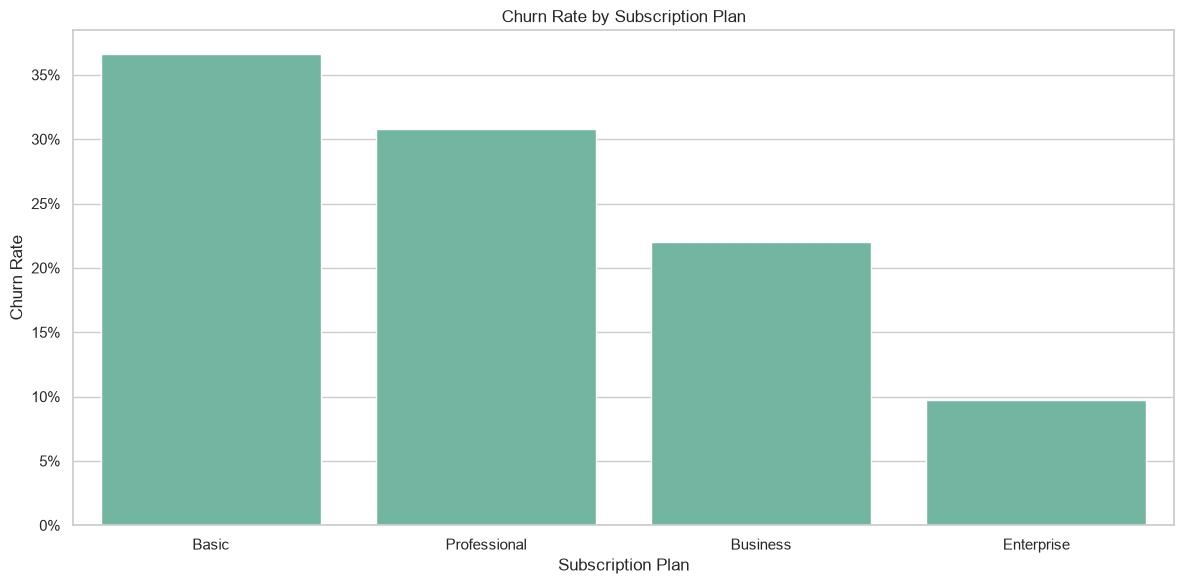

2026-07-08 21:20:35,428 - INFO - Subscription Plan insight: Basic has the highest observed churn rate at 36.6%.


Business insight - Subscription Plan: Basic has the highest observed churn rate at 36.6%.


In [9]:
if "subscription_plan" in customers.columns:
    plan_churn = (
        customers.groupby("subscription_plan", observed=False)[TARGET_COLUMN]
        .agg(churn_rate="mean", customers="size")
        .reset_index()
        .sort_values("churn_rate", ascending=False)
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=plan_churn, x="subscription_plan", y="churn_rate", ax=ax)
    ax.set_title("Churn Rate by Subscription Plan")
    ax.set_xlabel("Subscription Plan")
    ax.set_ylabel("Churn Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "churn_by_subscription_plan.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    top_plan = plan_churn.iloc[0]
    add_business_insight(
        "Subscription Plan",
        f"{top_plan['subscription_plan']} has the highest observed churn rate "
        f"at {top_plan['churn_rate']:.1%}."
    )
else:
    logger.info("subscription_plan column not available; skipped plan churn chart.")

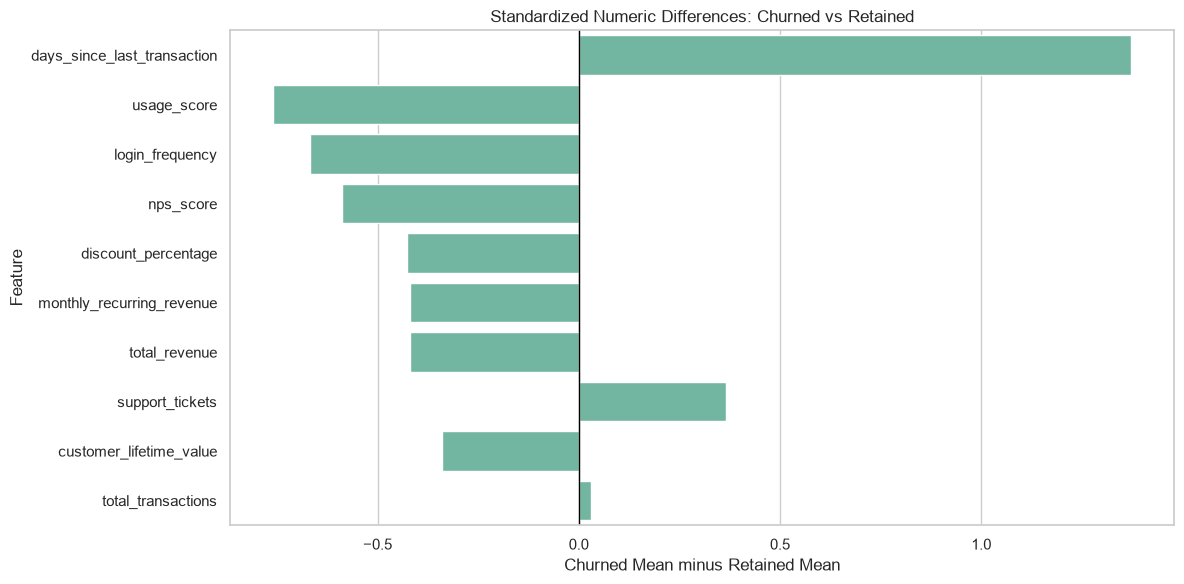

2026-07-08 21:20:35,673 - INFO - Numeric Churn Signals insight: days_since_last_transaction shows the largest standardized gap between churned and retained customers.


Business insight - Numeric Churn Signals: days_since_last_transaction shows the largest standardized gap between churned and retained customers.


In [10]:
numeric_eda_candidates = [
    "days_since_last_transaction",
    "usage_score",
    "login_frequency",
    "nps_score",
    "support_tickets",
    "discount_percentage",
    "monthly_recurring_revenue",
    "customer_lifetime_value",
    "total_transactions",
    "total_revenue",
]
available_numeric_eda = [column for column in numeric_eda_candidates if column in customers.columns]

if available_numeric_eda:
    standardized = customers[[TARGET_COLUMN] + available_numeric_eda].copy()
    standardized[available_numeric_eda] = standardized[available_numeric_eda].apply(pd.to_numeric, errors="coerce")
    standardized[available_numeric_eda] = (
        standardized[available_numeric_eda] - standardized[available_numeric_eda].mean()
    ) / standardized[available_numeric_eda].std(ddof=0).replace(0, np.nan)

    numeric_gap = (
        standardized.groupby(TARGET_COLUMN)[available_numeric_eda]
        .mean()
        .T
        .rename(columns={0: "retained_mean", 1: "churned_mean"})
        .assign(mean_gap=lambda data: data["churned_mean"] - data["retained_mean"])
        .reset_index()
        .rename(columns={"index": "feature"})
        .sort_values("mean_gap", key=lambda values: values.abs(), ascending=False)
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=numeric_gap, x="mean_gap", y="feature", ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Standardized Numeric Differences: Churned vs Retained")
    ax.set_xlabel("Churned Mean minus Retained Mean")
    ax.set_ylabel("Feature")

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "churn_numeric_mean_differences.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    largest_gap = numeric_gap.iloc[0]
    add_business_insight(
        "Numeric Churn Signals",
        f"{largest_gap['feature']} shows the largest standardized gap between churned "
        f"and retained customers."
    )
else:
    logger.info("No configured numeric EDA columns were available.")

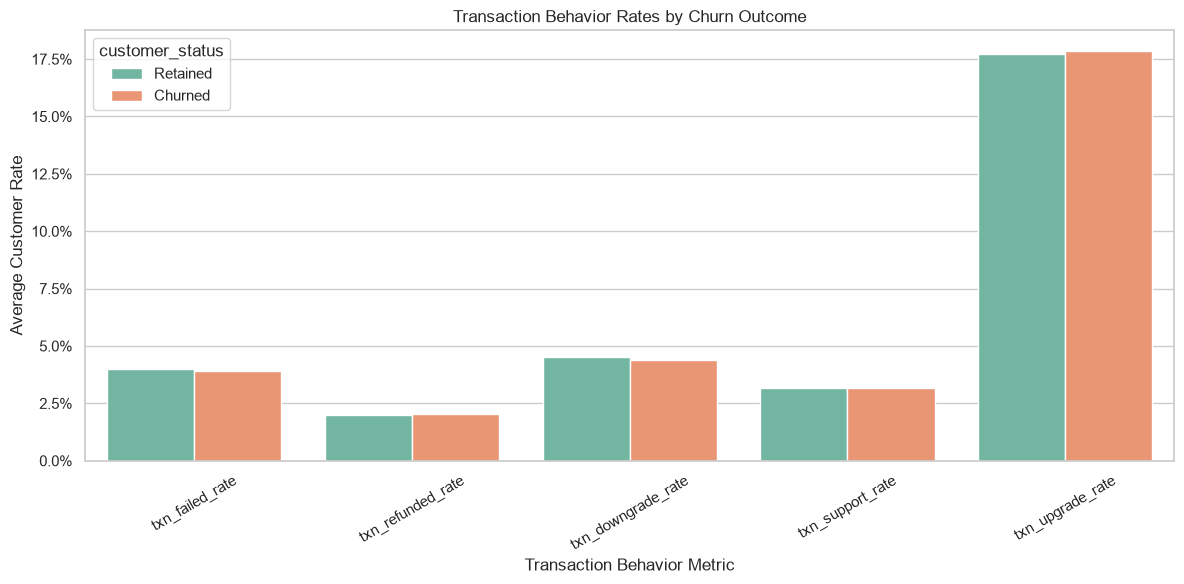

2026-07-08 21:20:36,006 - INFO - Transaction Behavior insight: Among transaction behavior metrics, txn_upgrade_rate is highest for churned customers at 17.9%.


Business insight - Transaction Behavior: Among transaction behavior metrics, txn_upgrade_rate is highest for churned customers at 17.9%.


In [11]:
transaction_rate_columns = [
    "txn_failed_rate",
    "txn_refunded_rate",
    "txn_downgrade_rate",
    "txn_support_rate",
    "txn_upgrade_rate",
]
available_rate_columns = [column for column in transaction_rate_columns if column in customers_with_txn.columns]

if available_rate_columns:
    transaction_rate_summary = (
        customers_with_txn.groupby(TARGET_COLUMN)[available_rate_columns]
        .mean()
        .T
        .rename(columns={0: "Retained", 1: "Churned"})
        .reset_index()
        .rename(columns={"index": "transaction_metric"})
        .melt(
            id_vars="transaction_metric",
            value_vars=["Retained", "Churned"],
            var_name="customer_status",
            value_name="average_rate",
        )
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(
        data=transaction_rate_summary,
        x="transaction_metric",
        y="average_rate",
        hue="customer_status",
        ax=ax,
    )
    ax.set_title("Transaction Behavior Rates by Churn Outcome")
    ax.set_xlabel("Transaction Behavior Metric")
    ax.set_ylabel("Average Customer Rate")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "churn_transaction_behavior.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    churned_rates = transaction_rate_summary[transaction_rate_summary["customer_status"] == "Churned"]
    leading_rate = churned_rates.sort_values("average_rate", ascending=False).iloc[0]
    add_business_insight(
        "Transaction Behavior",
        f"Among transaction behavior metrics, {leading_rate['transaction_metric']} is highest "
        f"for churned customers at {leading_rate['average_rate']:.1%}."
    )
else:
    logger.info("Transaction rate columns unavailable; skipped transaction behavior chart.")

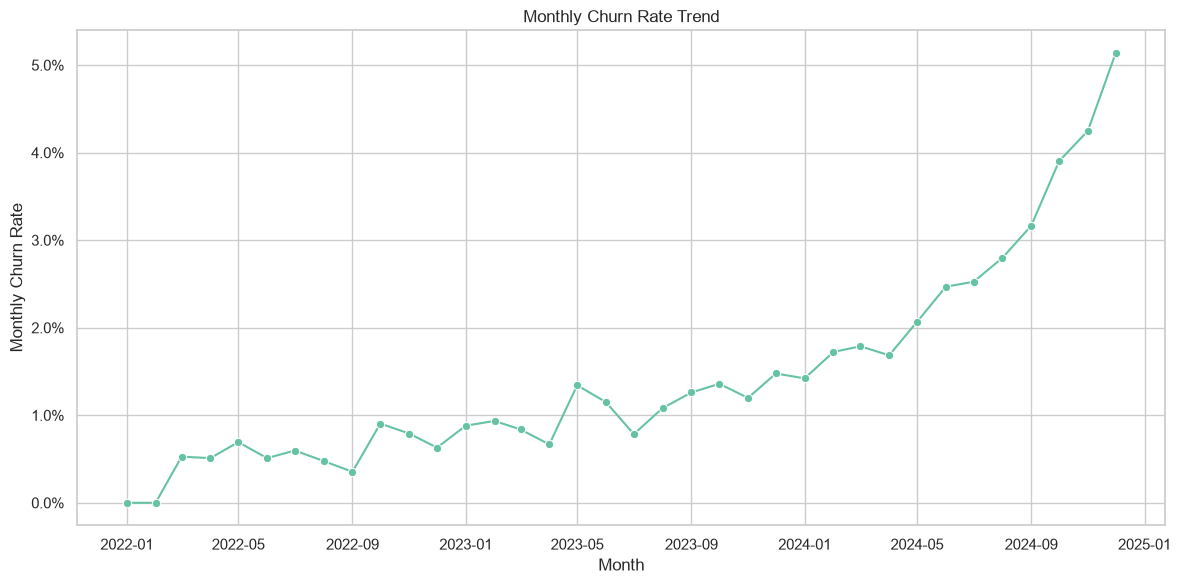

2026-07-08 21:20:36,277 - INFO - Monthly Churn Trend insight: The latest monthly churn rate is 5.1% for 2024-12-01.


Business insight - Monthly Churn Trend: The latest monthly churn rate is 5.1% for 2024-12-01.


In [12]:
if monthly_raw is not None and {"year_month", "churned_customers", "active_customers"}.issubset(monthly_raw.columns):
    monthly_churn = monthly_raw.copy()
    monthly_churn["year_month"] = pd.to_datetime(monthly_churn["year_month"], errors="coerce")
    monthly_churn["monthly_churn_rate"] = (
        monthly_churn["churned_customers"] / monthly_churn["active_customers"].replace(0, np.nan)
    )

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.lineplot(data=monthly_churn, x="year_month", y="monthly_churn_rate", marker="o", ax=ax)
    ax.set_title("Monthly Churn Rate Trend")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly Churn Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "monthly_churn_rate_trend.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    latest_month = monthly_churn.sort_values("year_month").iloc[-1]
    add_business_insight(
        "Monthly Churn Trend",
        f"The latest monthly churn rate is {latest_month['monthly_churn_rate']:.1%} "
        f"for {latest_month['year_month'].date()}."
    )
else:
    logger.info("Monthly churn columns unavailable; skipped monthly churn trend chart.")

# 9. Feature Engineering

Feature engineering keeps the customer as the unit of analysis. It adds date-derived fields, customer behavior ratios, and transaction aggregates while separating target fields from predictive inputs.

In [13]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Safely divide two numeric series and replace invalid values with zero."""
    result = numerator / denominator.replace(0, np.nan)
    return result.replace([np.inf, -np.inf], np.nan).fillna(0)


def add_date_parts(data: pd.DataFrame, date_columns: Iterable[str]) -> pd.DataFrame:
    """Add year, month, and quarter features from date columns."""
    output = data.copy()
    for column in date_columns:
        if column not in output.columns:
            continue
        parsed = pd.to_datetime(output[column], errors="coerce")
        output[f"{column}_year"] = parsed.dt.year
        output[f"{column}_month"] = parsed.dt.month
        output[f"{column}_quarter"] = parsed.dt.quarter
    return output


def engineer_customer_features(
    customers: pd.DataFrame,
    transaction_features: pd.DataFrame,
) -> pd.DataFrame:
    """Create model-ready customer features from available processed datasets."""
    features = customers.copy()
    features = add_date_parts(features, ["signup_date", "last_transaction_date", "acquisition_month"])

    if CUSTOMER_ID_COLUMN in features.columns and CUSTOMER_ID_COLUMN in transaction_features.columns:
        features = features.merge(transaction_features, on=CUSTOMER_ID_COLUMN, how="left")

    numeric_columns = features.select_dtypes(include=np.number).columns.tolist()
    features[numeric_columns] = features[numeric_columns].fillna(0)

    if {"support_tickets", "tenure_months"}.issubset(features.columns):
        features["support_tickets_per_tenure_month"] = safe_divide(
            pd.to_numeric(features["support_tickets"], errors="coerce"),
            pd.to_numeric(features["tenure_months"], errors="coerce") + 1,
        )
    if {"total_revenue", "total_transactions"}.issubset(features.columns):
        features["revenue_per_customer_transaction"] = safe_divide(
            pd.to_numeric(features["total_revenue"], errors="coerce"),
            pd.to_numeric(features["total_transactions"], errors="coerce"),
        )
    if {"total_profit", "total_revenue"}.issubset(features.columns):
        features["customer_profit_margin_calculated"] = safe_divide(
            pd.to_numeric(features["total_profit"], errors="coerce"),
            pd.to_numeric(features["total_revenue"], errors="coerce"),
        )
    if {"discount_percentage", "monthly_recurring_revenue"}.issubset(features.columns):
        features["discount_to_mrr_ratio"] = safe_divide(
            pd.to_numeric(features["discount_percentage"], errors="coerce"),
            pd.to_numeric(features["monthly_recurring_revenue"], errors="coerce"),
        )
    if {"login_frequency", "tenure_months"}.issubset(features.columns):
        features["login_frequency_per_tenure_month"] = safe_divide(
            pd.to_numeric(features["login_frequency"], errors="coerce"),
            pd.to_numeric(features["tenure_months"], errors="coerce") + 1,
        )
    return features


modeling_df = engineer_customer_features(customers, transaction_behavior)
logger.info("Engineered modeling dataset shape: %s", modeling_df.shape)
display(modeling_df.head())

2026-07-08 21:20:36,319 - INFO - Engineered modeling dataset shape: (20000, 69)


,customer_id,signup_date,customer_age,country,region,city,industry,company_size,subscription_plan,contract_type,contract_length_months,monthly_recurring_revenue,payment_method,support_tickets,usage_score,login_frequency,nps_score,discount_percentage,tenure_months,customer_segment,customer_lifetime_value,customer_acquisition_cost,acquisition_channel,acquisition_month,is_active,churn,last_transaction_date,days_since_last_transaction,frequency_score,monetary_score,average_transaction_value,total_transactions,total_revenue,total_profit,customer_profitability,risk_score,churn_target,signup_date_year,signup_date_month,signup_date_quarter,last_transaction_date_year,last_transaction_date_month,last_transaction_date_quarter,acquisition_month_year,acquisition_month_month,acquisition_month_quarter,txn_count_from_transactions,txn_net_revenue_sum,txn_profit_sum,txn_gross_amount_sum,txn_refund_amount_sum,txn_avg_payment_delay_days,txn_last_transaction_date,txn_completed_count,txn_failed_count,txn_refunded_count,txn_downgrade_count,txn_upgrade_count,txn_support_count,txn_failed_rate,txn_refunded_rate,txn_downgrade_rate,txn_upgrade_rate,txn_support_rate,support_tickets_per_tenure_month,revenue_per_customer_transaction,customer_profit_margin_calculated,discount_to_mrr_ratio,login_frequency_per_tenure_month
0,CUST_000000,2023-07-31,49,Germany,Europe,North Judithbury,Healthcare,Mid-Market,Enterprise,Annual,12,3820.0800,Credit Card,6.0000,48.7000,21.1000,-15.0000,8.1000,17,Core,29255.4500,3707.9200,Outbound Sales,2023-07,1,0,2024-11-27,34,2,5,6300.5900,15,94508.8700,79350.7600,Top,12.0000,0,2023,7,3,2024,11,4,2023,7,3,16,122960.0100,106865.5500,138373.4100,0.0000,2.9375,2024-11-27,15,1,0,0,3,0,0.0625,0.0000,0.0000,0.1875,0.0000,0.3333,6300.5913,0.8396,0.0021,1.1722
1,CUST_000001,2024-10-28,36,India,APAC,East Jill,Technology,Startup,Professional,Monthly,1,82.4300,Credit Card,5.0000,61.0000,21.2000,8.0000,0.0000,2,New / Onboarding,228.9700,75.1500,Organic Search,2024-10,1,0,2024-12-25,6,3,3,177.9800,16,2847.7500,2240.8100,Medium,36.0000,0,2024,10,4,2024,12,4,2024,10,4,18,2847.7500,2148.6700,3350.1300,156.4300,1.7222,2024-12-25,15,2,1,1,3,0,0.1111,0.0556,0.0556,0.1667,0.0000,1.6667,177.9844,0.7869,0.0000,7.0667
2,CUST_000002,2024-05-26,33,UK,Europe,New Roberttown,Technology,Startup,Basic,Monthly,1,38.9200,PayPal,3.0000,39.9000,12.1000,7.0000,2.1000,7,Core,61.2600,85.1000,Content Marketing,2024-05,1,0,2024-12-15,16,3,2,72.5100,16,1160.0900,788.0500,Low,62.2000,0,2024,5,2,2024,12,4,2024,5,2,16,1160.0900,788.0500,1249.5800,63.2500,2.5625,2024-12-15,15,0,1,1,7,0,0.0000,0.0625,0.0625,0.4375,0.0000,0.3750,72.5056,0.6793,0.0540,1.5125
3,CUST_000003,2024-02-12,38,USA,North America,East Jessetown,Technology,Small Business,Professional,Annual,12,185.7100,Credit Card,5.0000,46.6000,14.1000,11.0000,6.2000,10,Core,600.6800,640.1400,Outbound Sales,2024-02,0,1,2024-07-09,175,2,3,292.1700,14,4090.3200,3325.0600,High,29.0000,1,2024,2,1,2024,7,3,2024,2,1,16,4090.3200,3214.7100,5190.3000,186.9200,3.8125,2024-07-09,13,2,1,1,4,0,0.1250,0.0625,0.0625,0.2500,0.0000,0.4545,292.1657,0.8129,0.0334,1.2818
4,CUST_000004,2022-11-30,61,USA,North America,Lake Debra,Technology,Small Business,Professional,Monthly,1,166.1300,ACH,2.0000,29.6000,7.0000,-17.0000,4.1000,25,Low Engagement,343.3600,314.3700,Content Marketing,2022-11,0,1,2023-05-20,591,1,2,224.3600,11,2467.9300,1955.0200,Medium,46.4000,1,2022,11,4,2023,5,2,2022,11,4,12,2467.9300,1915.4400,2827.8000,0.0000,2.0000,2023-05-20,11,1,0,0,1,1,0.0833,0.0000,0.0000,0.0833,0.0833,0.0769,224.3573,0.7922,0.0247,0.2692


# 10. Feature Selection

The selected feature set removes identifiers, raw date strings, target fields, and leakage columns. `is_active` is excluded because it perfectly identifies churn. `risk_score`, `customer_segment`, and `customer_profitability` are excluded because they are precomputed business labels rather than independent behavioral inputs.

In [14]:
def select_model_features(
    data: pd.DataFrame,
    target_column: str,
    target_audit: Dict[str, Any],
) -> Tuple[pd.DataFrame, pd.Series, List[str], List[str], pd.DataFrame]:
    """Select valid model features and return an audit table."""
    source_target_column = target_audit.get("source_column")
    exclude_columns = {
        target_column,
        source_target_column,
        CUSTOMER_ID_COLUMN,
        "signup_date",
        "last_transaction_date",
        "acquisition_month",
        "txn_last_transaction_date",
        "is_active",
        "risk_score",
        "customer_segment",
        "customer_profitability",
    }
    exclude_columns = {column for column in exclude_columns if column in data.columns}
    candidate_features = data.drop(columns=list(exclude_columns), errors="ignore").copy()

    single_value_columns = [
        column for column in candidate_features.columns if candidate_features[column].nunique(dropna=True) <= 1
    ]
    high_cardinality_columns = [
        column
        for column in candidate_features.select_dtypes(exclude=np.number).columns
        if candidate_features[column].nunique(dropna=True) > 50
    ]
    candidate_features = candidate_features.drop(
        columns=single_value_columns + high_cardinality_columns,
        errors="ignore",
    )

    numeric_features = candidate_features.select_dtypes(include=np.number).columns.tolist()
    categorical_features = candidate_features.select_dtypes(exclude=np.number).columns.tolist()

    audit_records = []
    for column in sorted(exclude_columns):
        audit_records.append({"column": column, "action": "excluded", "reason": "identifier_target_or_leakage"})
    for column in single_value_columns:
        audit_records.append({"column": column, "action": "excluded", "reason": "single_value"})
    for column in high_cardinality_columns:
        audit_records.append({"column": column, "action": "excluded", "reason": "high_cardinality"})
    for column in numeric_features:
        audit_records.append({"column": column, "action": "included", "reason": "numeric_feature"})
    for column in categorical_features:
        audit_records.append({"column": column, "action": "included", "reason": "categorical_feature"})

    return candidate_features, data[target_column].astype(int), numeric_features, categorical_features, pd.DataFrame(audit_records)


X, y, numeric_features, categorical_features, feature_selection_audit = select_model_features(
    modeling_df,
    TARGET_COLUMN,
    target_audit,
)

print(f"Selected {len(numeric_features)} numeric features and {len(categorical_features)} categorical features.")
display(feature_selection_audit.groupby(["action", "reason"]).size().reset_index(name="columns"))
display(feature_selection_audit[feature_selection_audit["action"] == "included"].head(30))

Selected 49 numeric features and 8 categorical features.


,action,reason,columns
0,excluded,high_cardinality,1
1,excluded,identifier_target_or_leakage,11
2,included,categorical_feature,8
3,included,numeric_feature,49


,column,action,reason
12,customer_age,included,numeric_feature
13,contract_length_months,included,numeric_feature
14,monthly_recurring_revenue,included,numeric_feature
15,support_tickets,included,numeric_feature
16,usage_score,included,numeric_feature
17,login_frequency,included,numeric_feature
18,nps_score,included,numeric_feature
19,discount_percentage,included,numeric_feature
20,tenure_months,included,numeric_feature
21,customer_lifetime_value,included,numeric_feature


# 11. Data Preprocessing

Numeric features are median-imputed and scaled. Categorical features are mode-imputed and one-hot encoded. The preprocessing object is defined here and fitted only on the training data.

In [15]:
def build_one_hot_encoder() -> OneHotEncoder:
    """Create a version-compatible one-hot encoder."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(
    numeric_columns: List[str],
    categorical_columns: List[str],
) -> ColumnTransformer:
    """Build preprocessing for numeric and categorical columns."""
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_columns),
            ("categorical", categorical_transformer, categorical_columns),
        ],
        remainder="drop",
    )


def get_feature_names(preprocessor: ColumnTransformer, sample: pd.DataFrame) -> np.ndarray:
    """Return feature names after preprocessing."""
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        feature_count = preprocessor.transform(sample.head(1)).shape[1]
        return np.array([f"feature_{index}" for index in range(feature_count)])


preprocessor = build_preprocessor(numeric_features, categorical_features)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

# 12. Train-Test Split

The split is stratified so churn prevalence remains consistent across train and test samples. Preprocessing is fitted on the training data only.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = get_feature_names(preprocessor, X_train)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")
print(f"Processed feature count: {len(feature_names):,}")

Training rows: 15,000
Test rows: 5,000
Training churn rate: 27.80%
Test churn rate: 27.80%
Processed feature count: 92


# 13. Handle Class Imbalance

If the minority class falls below 20% and `imblearn` is installed, SMOTE is applied to the processed training matrix. Otherwise, the workflow keeps the original sample and uses class-weighted estimators where supported.

In [17]:
class_distribution = y_train.value_counts(normalize=True).rename("share").reset_index()
class_distribution.columns = ["churn_target", "share"]
minority_share = class_distribution["share"].min()
use_smote = bool(minority_share < 0.20 and SMOTE_AVAILABLE)

if use_smote:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_model, y_train_model = smote.fit_resample(X_train_processed, y_train)
    imbalance_strategy = "SMOTE oversampling applied to training data."
else:
    X_train_model, y_train_model = X_train_processed, y_train
    imbalance_strategy = "No resampling required; class-weighted estimators used where supported."

print(f"Training minority class share: {minority_share:.2%}")
print(imbalance_strategy)
print(pd.Series(y_train_model).value_counts().sort_index())

Training minority class share: 27.80%
No resampling required; class-weighted estimators used where supported.
churn_target
0    10830
1     4170
Name: count, dtype: int64


# 14. Baseline Model

A majority-class dummy classifier establishes the minimum useful benchmark for the churn models.

In [18]:
evaluation_records: List[Dict[str, float]] = []
trained_models: Dict[str, Any] = {}
test_predictions: Dict[str, Dict[str, np.ndarray]] = {}


def predict_probabilities(model: Any, features: np.ndarray) -> np.ndarray:
    """Return positive-class probabilities for classifiers."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(features)
        return (scores - scores.min()) / (scores.max() - scores.min())
    return model.predict(features)


def evaluate_classifier(
    name: str,
    model: Any,
    features: np.ndarray,
    actual: pd.Series,
    threshold: float = 0.50,
) -> Dict[str, float]:
    """Evaluate a binary classifier and store predictions."""
    probabilities = predict_probabilities(model, features)
    predicted = (probabilities >= threshold).astype(int)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(actual, predicted),
        "precision": precision_score(actual, predicted, zero_division=0),
        "recall": recall_score(actual, predicted, zero_division=0),
        "f1": f1_score(actual, predicted, zero_division=0),
        "roc_auc": roc_auc_score(actual, probabilities),
        "average_precision": average_precision_score(actual, probabilities),
    }
    test_predictions[name] = {"probability": probabilities, "label": predicted}
    return metrics


baseline_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_model.fit(X_train_processed, y_train)
trained_models["Baseline"] = baseline_model
evaluation_records.append(evaluate_classifier("Baseline", baseline_model, X_test_processed, y_test))
display(pd.DataFrame([evaluation_records[-1]]))

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Baseline,0.7220,0.0000,0.0000,0.0000,0.5000,0.2780


# 15. Logistic Regression

Logistic regression provides an interpretable linear benchmark. Class weighting is enabled because churn is the minority class.

In [19]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
logistic_model.fit(X_train_model, y_train_model)
trained_models["Logistic Regression"] = logistic_model
evaluation_records.append(evaluate_classifier("Logistic Regression", logistic_model, X_test_processed, y_test))
display(pd.DataFrame([evaluation_records[-1]]))

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.9562,0.9234,0.9187,0.9210,0.9838,0.9730


# 16. Decision Tree

A constrained decision tree captures non-linear churn patterns while limiting overfitting through depth and leaf-size controls.

In [20]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
decision_tree_model.fit(X_train_model, y_train_model)
trained_models["Decision Tree"] = decision_tree_model
evaluation_records.append(evaluate_classifier("Decision Tree", decision_tree_model, X_test_processed, y_test))
display(pd.DataFrame([evaluation_records[-1]]))

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Decision Tree,0.9442,0.8855,0.9180,0.9014,0.9690,0.9556


# 17. Random Forest

Random forest improves stability by averaging many decision trees and works well with mixed behavioral, subscription, and transaction features.

In [21]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest_model.fit(X_train_model, y_train_model)
trained_models["Random Forest"] = random_forest_model
evaluation_records.append(evaluate_classifier("Random Forest", random_forest_model, X_test_processed, y_test))
display(pd.DataFrame([evaluation_records[-1]]))

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.9532,0.9558,0.8719,0.9120,0.9811,0.9682


# 18. XGBoost (Optional)

XGBoost is trained only if the package is installed. If unavailable, the notebook logs a skip message and continues with the other models.

In [22]:
if XGB_AVAILABLE:
    negative_count = int((y_train_model == 0).sum())
    positive_count = int((y_train_model == 1).sum())
    scale_pos_weight = negative_count / max(positive_count, 1)

    xgboost_model = XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgboost_model.fit(X_train_model, y_train_model)
    trained_models["XGBoost"] = xgboost_model
    evaluation_records.append(evaluate_classifier("XGBoost", xgboost_model, X_test_processed, y_test))
    display(pd.DataFrame([evaluation_records[-1]]))
else:
    logger.warning("XGBoost is not installed; skipped optional XGBoost model.")
    print("XGBoost is not installed; skipped optional model.")

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,XGBoost,0.9650,0.9490,0.9237,0.9362,0.9880,0.9802


# 19. Model Comparison

Models are compared on accuracy, precision, recall, F1, ROC-AUC, and average precision. The best model is selected by ROC-AUC, with F1 and recall reviewed as supporting churn metrics.

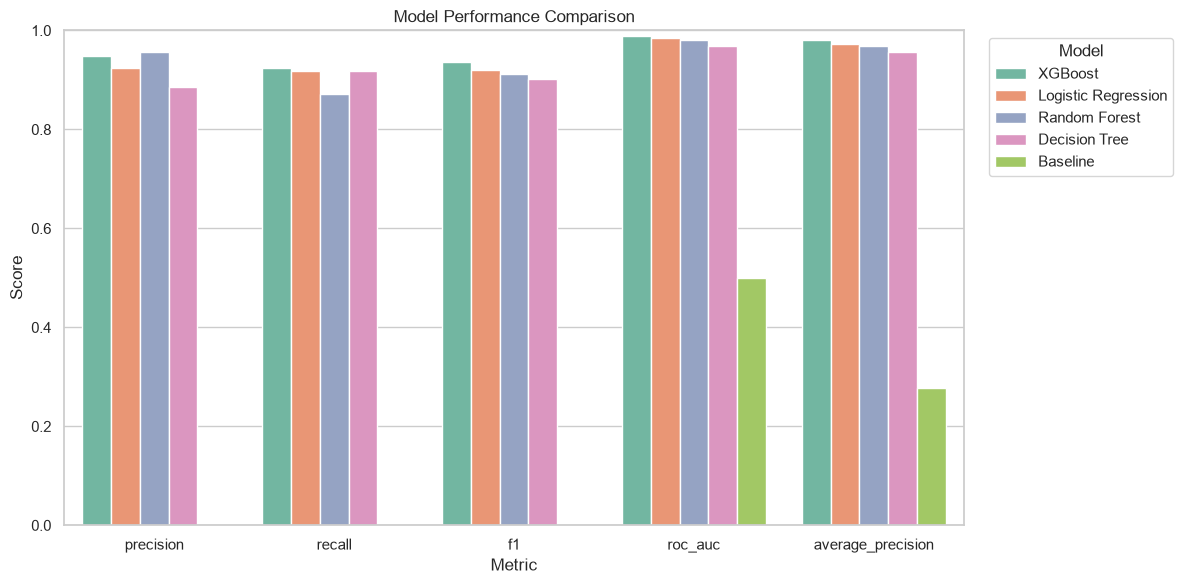

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,XGBoost,0.9650,0.9490,0.9237,0.9362,0.9880,0.9802
1,Logistic Regression,0.9562,0.9234,0.9187,0.9210,0.9838,0.9730
2,Random Forest,0.9532,0.9558,0.8719,0.9120,0.9811,0.9682
3,Decision Tree,0.9442,0.8855,0.9180,0.9014,0.9690,0.9556
4,Baseline,0.7220,0.0000,0.0000,0.0000,0.5000,0.2780


2026-07-08 21:20:39,264 - INFO - Model Comparison insight: XGBoost is the leading model by ROC-AUC at 0.988.


Business insight - Model Comparison: XGBoost is the leading model by ROC-AUC at 0.988.


In [23]:
metrics_df = pd.DataFrame(evaluation_records).sort_values("roc_auc", ascending=False).reset_index(drop=True)
best_model_name = str(metrics_df.iloc[0]["model"])
best_model = trained_models[best_model_name]
comparison_plot_df = metrics_df.melt(
    id_vars="model",
    value_vars=["precision", "recall", "f1", "roc_auc", "average_precision"],
    var_name="metric",
    value_name="score",
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=comparison_plot_df, x="metric", y="score", hue="model", ax=ax)
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

display(metrics_df)
add_business_insight(
    "Model Comparison",
    f"{best_model_name} is the leading model by ROC-AUC at {metrics_df.iloc[0]['roc_auc']:.3f}."
)

# 20. Cross Validation

Cross validation checks whether model performance is stable across stratified folds. The preprocessing pipeline is rebuilt inside each fold to avoid leakage.

In [24]:
def build_model_candidates() -> Dict[str, Any]:
    """Create fresh estimators for cross validation."""
    candidates: Dict[str, Any] = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=150,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }
    if XGB_AVAILABLE:
        negative_count = int((y == 0).sum())
        positive_count = int((y == 1).sum())
        candidates["XGBoost"] = XGBClassifier(
            n_estimators=150,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=negative_count / max(positive_count, 1),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    return candidates


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}
cv_records = []

for model_name, estimator in build_model_candidates().items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
            ("model", estimator),
        ]
    )
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score="raise",
    )
    cv_records.append(
        {
            "model": model_name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
            "f1_mean": scores["test_f1"].mean(),
            "precision_mean": scores["test_precision"].mean(),
            "recall_mean": scores["test_recall"].mean(),
        }
    )

cv_results_df = pd.DataFrame(cv_records).sort_values("roc_auc_mean", ascending=False)
display(cv_results_df)

,model,roc_auc_mean,roc_auc_std,f1_mean,precision_mean,recall_mean
3,XGBoost,0.9895,0.0018,0.9361,0.9431,0.9293
0,Logistic Regression,0.9853,0.0014,0.9206,0.9201,0.9212
2,Random Forest,0.9810,0.0018,0.9124,0.9486,0.8790
1,Decision Tree,0.9747,0.0044,0.9117,0.9059,0.9176


# 21. Confusion Matrix

The confusion matrix shows retained/churned classification outcomes at the default 0.50 threshold for the selected model.

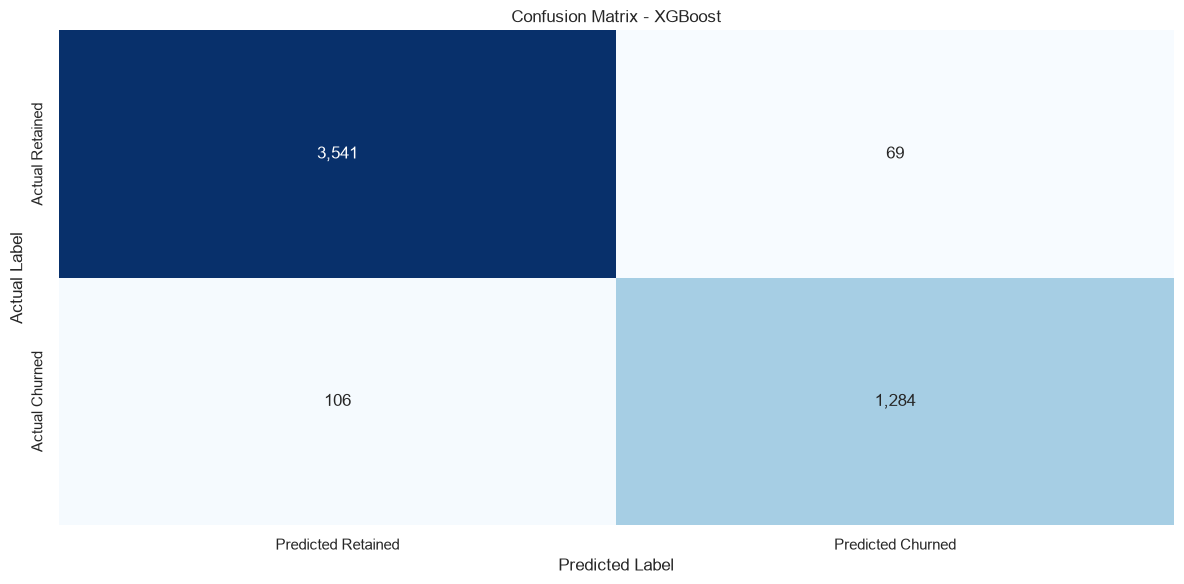

2026-07-08 21:20:48,352 - INFO - Confusion Matrix insight: At the default threshold, the model captures 1,284 churners and misses 106 churners in the test set.


Business insight - Confusion Matrix: At the default threshold, the model captures 1,284 churners and misses 106 churners in the test set.


In [25]:
best_predictions = test_predictions[best_model_name]["label"]
cm = confusion_matrix(y_test, best_predictions)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Retained", "Actual Churned"],
    columns=["Predicted Retained", "Predicted Churned"],
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Confusion Matrix - {best_model_name}")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

add_business_insight(
    "Confusion Matrix",
    f"At the default threshold, the model captures {int(cm[1, 1]):,} churners "
    f"and misses {int(cm[1, 0]):,} churners in the test set."
)

# 22. ROC Curve

The ROC curve compares class separation across probability thresholds for every trained model.

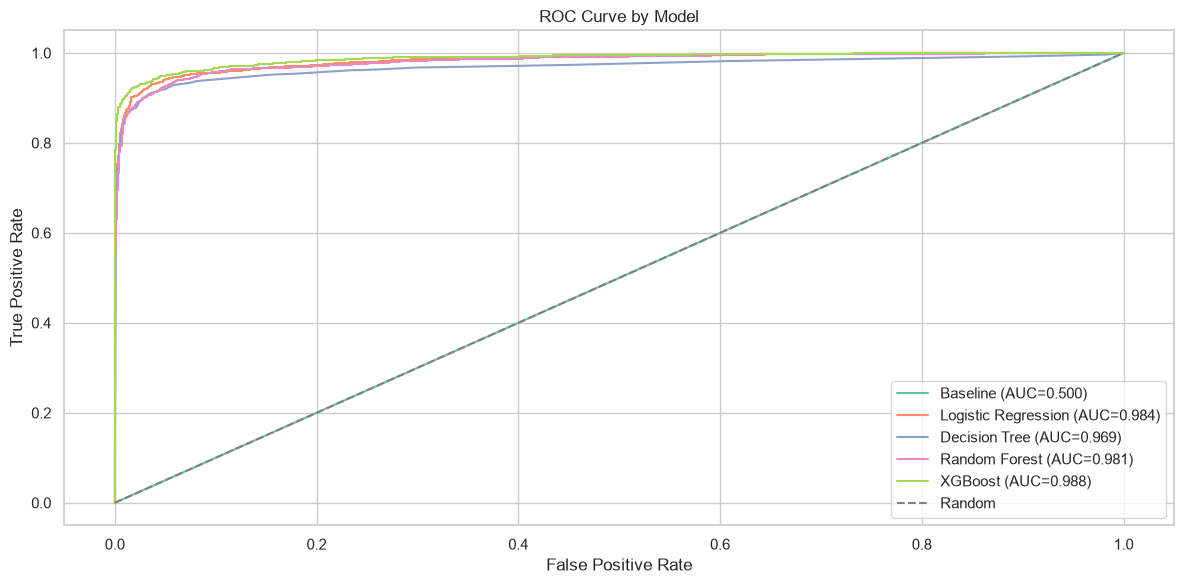

2026-07-08 21:20:48,629 - INFO - ROC Curve insight: XGBoost provides the strongest class separation with ROC-AUC 0.988.


Business insight - ROC Curve: XGBoost provides the strongest class separation with ROC-AUC 0.988.


In [26]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
for model_name, predictions in test_predictions.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, predictions["probability"])
    model_auc = roc_auc_score(y_test, predictions["probability"])
    ax.plot(false_positive_rate, true_positive_rate, label=f"{model_name} (AUC={model_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_title("ROC Curve by Model")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

add_business_insight(
    "ROC Curve",
    f"{best_model_name} provides the strongest class separation with ROC-AUC "
    f"{metrics_df.iloc[0]['roc_auc']:.3f}."
)

# 23. Precision-Recall Analysis

Precision-recall analysis supports threshold selection for churn outreach, where the business may need to balance broad coverage against retention capacity.

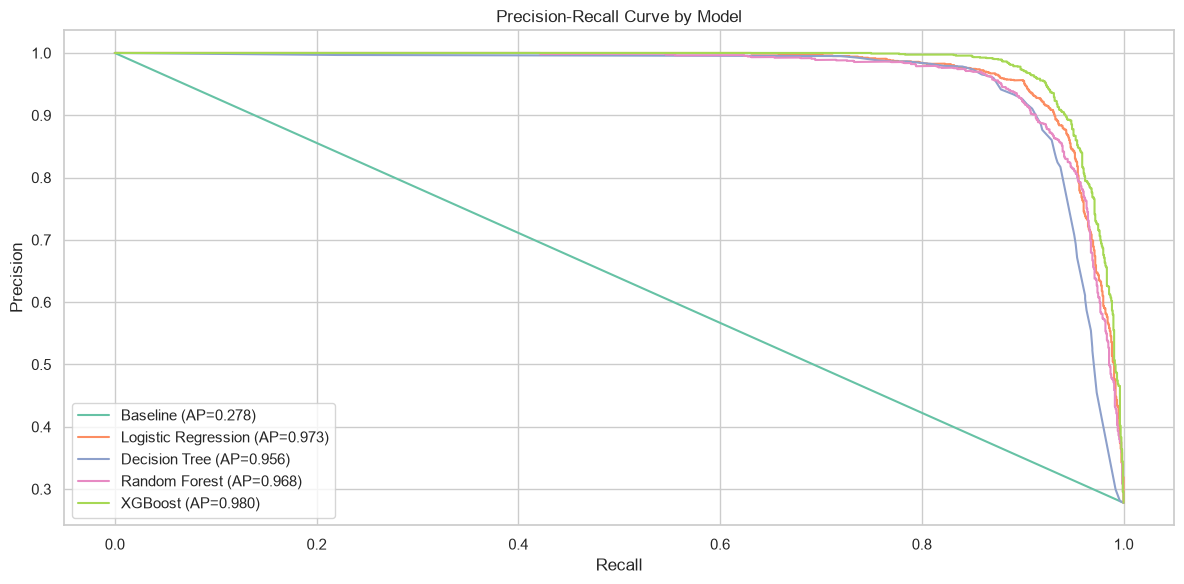

,threshold,precision,recall,f1
3656,0.5272,0.9539,0.9223,0.9378
3658,0.5335,0.9545,0.9216,0.9378
3660,0.5417,0.9552,0.9209,0.9377
3662,0.5453,0.9559,0.9201,0.9377
3670,0.5768,0.9586,0.9173,0.9375
3655,0.5194,0.9532,0.9223,0.9375
3657,0.5304,0.9538,0.9216,0.9374
3659,0.5343,0.9545,0.9209,0.9374
3661,0.5441,0.9552,0.9201,0.9373
3663,0.5526,0.9559,0.9194,0.9373


2026-07-08 21:20:49,054 - INFO - Precision-Recall insight: The best tested F1 threshold for XGBoost is 0.53.


Business insight - Precision-Recall: The best tested F1 threshold for XGBoost is 0.53.


In [27]:
# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
for model_name, predictions in test_predictions.items():
    precision_values, recall_values, _ = precision_recall_curve(y_test, predictions["probability"])
    avg_precision = average_precision_score(y_test, predictions["probability"])
    ax.plot(recall_values, precision_values, label=f"{model_name} (AP={avg_precision:.3f})")
ax.set_title("Precision-Recall Curve by Model")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

best_probability = test_predictions[best_model_name]["probability"]
precision_values, recall_values, threshold_values = precision_recall_curve(y_test, best_probability)
threshold_table = pd.DataFrame(
    {
        "threshold": threshold_values,
        "precision": precision_values[:-1],
        "recall": recall_values[:-1],
    }
)
threshold_table["f1"] = 2 * (
    threshold_table["precision"] * threshold_table["recall"]
) / (threshold_table["precision"] + threshold_table["recall"]).replace(0, np.nan)
threshold_table = threshold_table.sort_values("f1", ascending=False).head(10)

display(threshold_table)
add_business_insight(
    "Precision-Recall",
    f"The best tested F1 threshold for {best_model_name} is {threshold_table.iloc[0]['threshold']:.2f}."
)

# 24. Feature Importance

Feature importance translates model behavior into business-readable churn signals. Tree-based models use native importance; linear models use absolute coefficients.

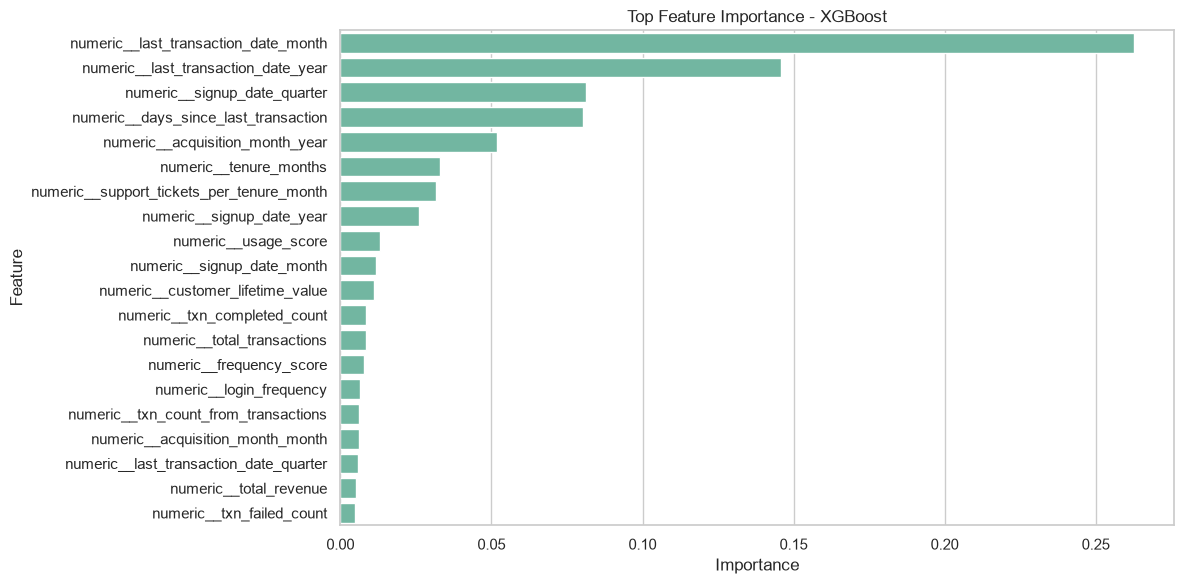

2026-07-08 21:20:49,686 - INFO - Feature Importance insight: numeric__last_transaction_date_month is the strongest model signal for churn risk.


Business insight - Feature Importance: numeric__last_transaction_date_month is the strongest model signal for churn risk.


In [28]:
def extract_feature_importance(model: Any, feature_names: np.ndarray) -> pd.DataFrame:
    """Extract feature importance from supported model types."""
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_).ravel()
    else:
        return pd.DataFrame(columns=["feature", "importance"])

    return (
        pd.DataFrame({"feature": feature_names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


feature_importance_df = extract_feature_importance(best_model, feature_names)

if not feature_importance_df.empty:
    top_feature_importance = feature_importance_df.head(20)

    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot
    sns.barplot(data=top_feature_importance, x="importance", y="feature", ax=ax)
    ax.set_title(f"Top Feature Importance - {best_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    # Improve layout
    plt.tight_layout()

    # Save
    plt.savefig(
        FIGURES_DIR / "feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Show inside notebook
    plt.show()

    add_business_insight(
        "Feature Importance",
        f"{top_feature_importance.iloc[0]['feature']} is the strongest model signal for churn risk."
    )
else:
    logger.info("Selected model does not expose feature importance.")
    print("Selected model does not expose feature importance.")

# 25. SHAP Analysis (Optional)

When SHAP is installed and the selected model is tree-based, this section calculates mean absolute SHAP impact for a sample of customers and plots the most influential features with `matplotlib` and `seaborn`.

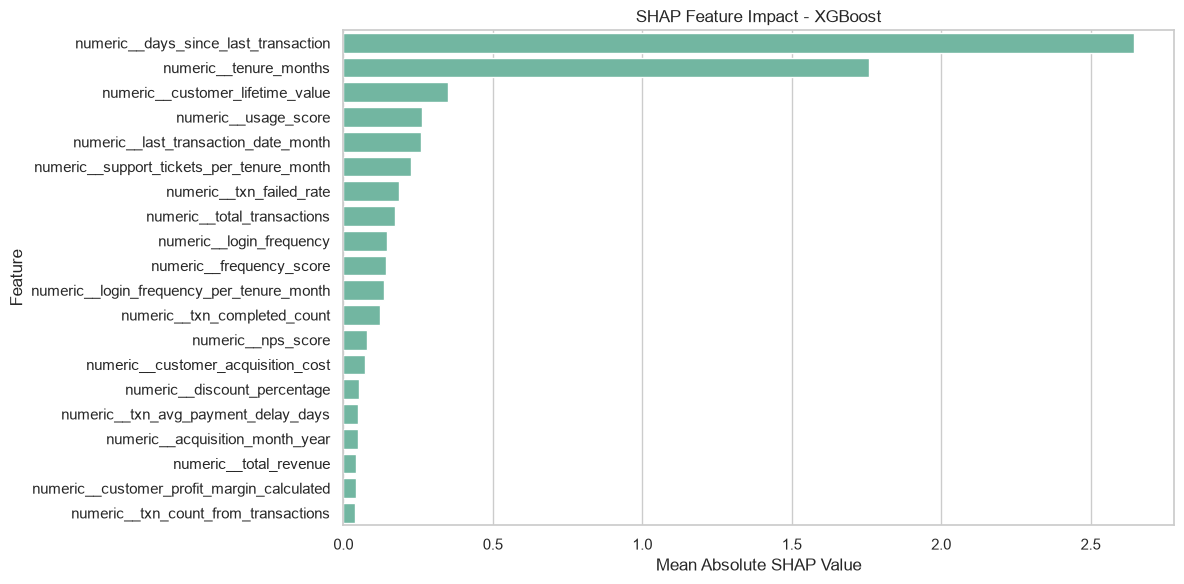

2026-07-08 21:20:50,190 - INFO - SHAP Analysis insight: SHAP confirms numeric__days_since_last_transaction as the top local impact driver.


Business insight - SHAP Analysis: SHAP confirms numeric__days_since_last_transaction as the top local impact driver.


In [29]:
shap_importance_df = pd.DataFrame(columns=["feature", "mean_abs_shap"])

if SHAP_AVAILABLE and hasattr(best_model, "feature_importances_"):
    shap_sample_size = min(1000, X_test_processed.shape[0])
    shap_sample = X_test_processed[:shap_sample_size]
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(shap_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[-1]

        shap_importance_df = (
            pd.DataFrame(
                {
                    "feature": feature_names,
                    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
                }
            )
            .sort_values("mean_abs_shap", ascending=False)
            .head(20)
        )

        # Create visualization
        fig, ax = plt.subplots(figsize=(12, 6))

        # Plot
        sns.barplot(data=shap_importance_df, x="mean_abs_shap", y="feature", ax=ax)
        ax.set_title(f"SHAP Feature Impact - {best_model_name}")
        ax.set_xlabel("Mean Absolute SHAP Value")
        ax.set_ylabel("Feature")

        # Improve layout
        plt.tight_layout()

        # Save
        plt.savefig(
            FIGURES_DIR / "shap_feature_impact.png",
            dpi=300,
            bbox_inches="tight"
        )

        # Show inside notebook
        plt.show()

        add_business_insight(
            "SHAP Analysis",
            f"SHAP confirms {shap_importance_df.iloc[0]['feature']} as the top local impact driver."
        )
    except Exception as exc:
        logger.warning("SHAP analysis skipped because it failed: %s", exc)
        print(f"SHAP analysis skipped because it failed: {exc}")
else:
    print("SHAP is unavailable or the selected model is not tree-based; skipped optional SHAP analysis.")

# 26. Customer Risk Segmentation

The selected model scores every customer and assigns operational churn risk bands from predicted probability. These bands support retention prioritization.

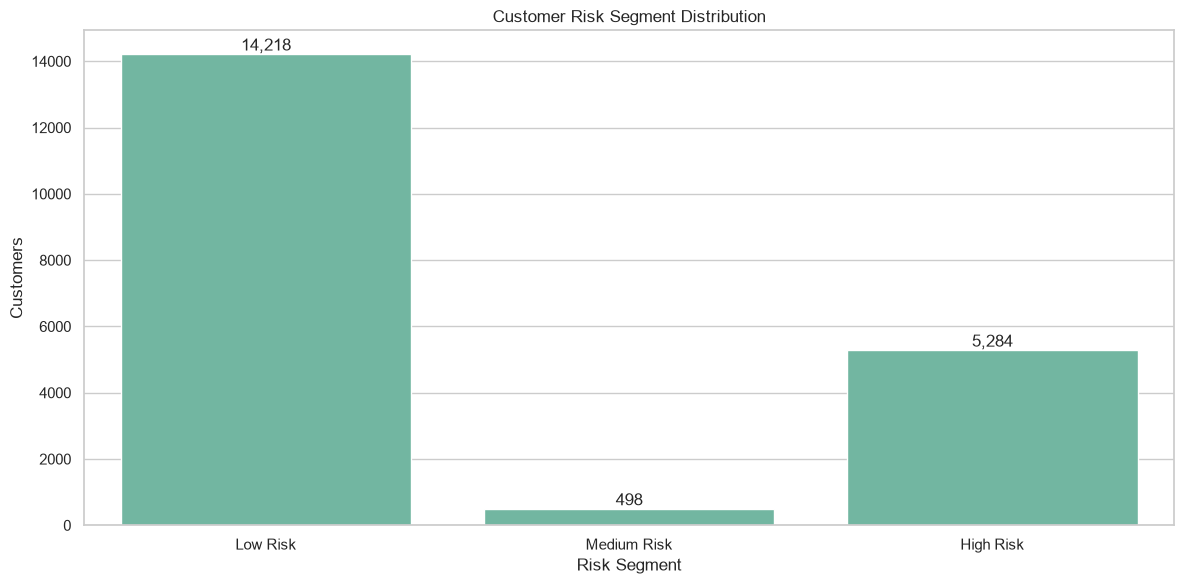

,risk_segment,customers,average_churn_probability,observed_churn_rate
0,Low Risk,14218,0.0421,0.0127
1,Medium Risk,498,0.4876,0.3936
2,High Risk,5284,0.9777,0.9811


2026-07-08 21:20:50,430 - INFO - Customer Risk Segmentation insight: 5,284 customers are classified as high risk using the 65% probability threshold.


Business insight - Customer Risk Segmentation: 5,284 customers are classified as high risk using the 65% probability threshold.


In [30]:
all_customer_features_processed = preprocessor.transform(X)
all_churn_probabilities = predict_probabilities(best_model, all_customer_features_processed)

prediction_columns = [CUSTOMER_ID_COLUMN] if CUSTOMER_ID_COLUMN in customers.columns else []
predictions_df = customers[prediction_columns].copy() if prediction_columns else pd.DataFrame(index=customers.index)
predictions_df["churn_probability"] = all_churn_probabilities
predictions_df["predicted_churn"] = (predictions_df["churn_probability"] >= 0.50).astype(int)
predictions_df["actual_churn"] = customers[TARGET_COLUMN].astype(int).values
predictions_df["risk_segment"] = pd.cut(
    predictions_df["churn_probability"],
    bins=[-0.001, MEDIUM_RISK_THRESHOLD, HIGH_RISK_THRESHOLD, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
)

risk_segment_summary = (
    predictions_df.groupby("risk_segment", observed=False)
    .agg(
        customers=("churn_probability", "size"),
        average_churn_probability=("churn_probability", "mean"),
        observed_churn_rate=("actual_churn", "mean"),
    )
    .reset_index()
)

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(data=risk_segment_summary, x="risk_segment", y="customers", ax=ax)
ax.set_title("Customer Risk Segment Distribution")
ax.set_xlabel("Risk Segment")
ax.set_ylabel("Customers")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}")

# Improve layout
plt.tight_layout()

# Save
plt.savefig(
    FIGURES_DIR / "risk_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show inside notebook
plt.show()

display(risk_segment_summary)
high_risk_count = int((predictions_df["risk_segment"] == "High Risk").sum())
add_business_insight(
    "Customer Risk Segmentation",
    f"{high_risk_count:,} customers are classified as high risk using the "
    f"{HIGH_RISK_THRESHOLD:.0%} probability threshold."
)

# 27. High Risk Customer Report

The high-risk customer report prioritizes customers by churn probability and retains relevant customer context fields available in the processed dataset.

In [31]:
context_columns = [
    CUSTOMER_ID_COLUMN,
    "country",
    "region",
    "industry",
    "company_size",
    "subscription_plan",
    "contract_type",
    "monthly_recurring_revenue",
    "support_tickets",
    "usage_score",
    "login_frequency",
    "nps_score",
    "tenure_months",
    "days_since_last_transaction",
    "total_transactions",
    "total_revenue",
    "total_profit",
]
context_columns = [column for column in context_columns if column in customers.columns]

high_risk_customers = (
    predictions_df.merge(customers[context_columns], on=CUSTOMER_ID_COLUMN, how="left")
    if CUSTOMER_ID_COLUMN in predictions_df.columns and CUSTOMER_ID_COLUMN in customers.columns
    else predictions_df.copy()
)
high_risk_customers = high_risk_customers[
    high_risk_customers["risk_segment"].astype(str).eq("High Risk")
].sort_values("churn_probability", ascending=False)

report_column_order = [
    column
    for column in [
        CUSTOMER_ID_COLUMN,
        "churn_probability",
        "predicted_churn",
        "actual_churn",
        "risk_segment",
        "country",
        "region",
        "industry",
        "company_size",
        "subscription_plan",
        "contract_type",
        "monthly_recurring_revenue",
        "support_tickets",
        "usage_score",
        "login_frequency",
        "nps_score",
        "tenure_months",
        "days_since_last_transaction",
        "total_transactions",
        "total_revenue",
        "total_profit",
    ]
    if column in high_risk_customers.columns
]
high_risk_customers = high_risk_customers[report_column_order]

display(high_risk_customers.head(20))
print(f"High-risk customers identified: {len(high_risk_customers):,}")

,customer_id,churn_probability,predicted_churn,actual_churn,risk_segment,country,region,industry,company_size,subscription_plan,contract_type,monthly_recurring_revenue,support_tickets,usage_score,login_frequency,nps_score,tenure_months,days_since_last_transaction,total_transactions,total_revenue,total_profit
5242,CUST_005242,0.9999,1,1,High Risk,USA,North America,Manufacturing,Startup,Basic,Monthly,30.7700,4.0000,23.9000,6.7000,-33.0000,13,247,24,1153.5000,733.7400
12496,CUST_012496,0.9999,1,1,High Risk,Canada,North America,Healthcare,Startup,Basic,Annual,38.2800,1.0000,19.1000,10.0000,-21.0000,9,249,17,1045.8600,698.7200
4733,CUST_004733,0.9999,1,1,High Risk,UK,Europe,Education,Startup,Basic,Annual,33.1700,5.0000,34.7000,5.1000,7.0000,2,47,18,1133.0000,792.9800
10097,CUST_010097,0.9999,1,1,High Risk,USA,North America,Real Estate,Startup,Professional,Monthly,83.3400,7.0000,44.2000,10.0000,-29.0000,7,188,21,3157.8100,2416.6600
18065,CUST_018065,0.9999,1,1,High Risk,USA,North America,Education,Startup,Basic,Annual,27.9300,6.0000,34.4000,10.6000,-26.0000,6,176,22,1011.6200,606.8800
15458,CUST_015458,0.9999,1,1,High Risk,USA,North America,Retail,Startup,Professional,Monthly,102.3200,7.0000,43.8000,8.8000,-12.0000,8,206,20,3492.0200,2775.0100
9633,CUST_009633,0.9999,1,1,High Risk,India,APAC,Other,Small Business,Business,Annual,403.7400,2.0000,58.5000,17.2000,9.0000,8,236,17,11903.3400,9940.4700
9966,CUST_009966,0.9999,1,1,High Risk,Australia,APAC,Real Estate,Startup,Professional,Monthly,92.6100,5.0000,32.1000,8.5000,4.0000,7,198,18,2954.8100,2271.2800
17139,CUST_017139,0.9999,1,1,High Risk,USA,North America,Real Estate,Mid-Market,Professional,Annual,383.1400,4.0000,52.3000,14.5000,-20.0000,7,190,19,12157.8500,9997.9000
2931,CUST_002931,0.9999,1,1,High Risk,USA,North America,Finance,Startup,Basic,Monthly,34.8000,6.0000,24.8000,13.4000,-7.0000,8,197,22,1289.1500,851.3200


High-risk customers identified: 5,284


# 28. Business Recommendations

Recommendations are generated from the observed churn patterns, model results, and high-risk customer profile. They focus only on retention actions supported by the processed datasets.

In [32]:
def build_business_recommendations() -> List[str]:
    """Build dataset-backed churn recommendations."""
    recommendations: List[str] = []

    if "contract_type" in customers.columns:
        contract_risk = customers.groupby("contract_type", observed=False)[TARGET_COLUMN].mean().sort_values(ascending=False)
        recommendations.append(
            f"Prioritize retention offers for {contract_risk.index[0]} contract customers, "
            f"where observed churn is {contract_risk.iloc[0]:.1%}."
        )

    if "subscription_plan" in customers.columns:
        plan_risk = customers.groupby("subscription_plan", observed=False)[TARGET_COLUMN].mean().sort_values(ascending=False)
        recommendations.append(
            f"Review onboarding and value realization for {plan_risk.index[0]} plan customers, "
            f"the plan with the highest churn rate at {plan_risk.iloc[0]:.1%}."
        )

    if not feature_importance_df.empty:
        top_features = feature_importance_df.head(3)["feature"].tolist()
        recommendations.append(
            "Use the leading model signals for intervention triggers: "
            + ", ".join(top_features)
            + "."
        )

    if len(high_risk_customers) > 0:
        recommendations.append(
            f"Create a retention queue for the {len(high_risk_customers):,} high-risk customers "
            f"with predicted churn probability at or above {HIGH_RISK_THRESHOLD:.0%}."
        )

    recommendations.append(
        "Monitor precision and recall before launching campaigns so retention capacity is aligned "
        "with the selected probability threshold."
    )
    return recommendations


business_recommendations = build_business_recommendations()
for index, recommendation in enumerate(business_recommendations, start=1):
    print(f"{index}. {recommendation}")

for recommendation in business_recommendations:
    business_insights.append({"section": "Business Recommendations", "insight": recommendation})

1. Prioritize retention offers for Monthly contract customers, where observed churn is 33.9%.
2. Review onboarding and value realization for Basic plan customers, the plan with the highest churn rate at 36.6%.
3. Use the leading model signals for intervention triggers: numeric__last_transaction_date_month, numeric__last_transaction_date_year, numeric__signup_date_quarter.
4. Create a retention queue for the 5,284 high-risk customers with predicted churn probability at or above 65%.
5. Monitor precision and recall before launching campaigns so retention capacity is aligned with the selected probability threshold.


# 29. Save Outputs

Model metrics, cross-validation results, predictions, feature importance, business insights, and the high-risk customer report are saved to `outputs/`.

In [33]:
metrics_path = OUTPUTS_DIR / "model_evaluation_metrics.csv"
cv_metrics_path = OUTPUTS_DIR / "cross_validation_metrics.csv"
predictions_path = OUTPUTS_DIR / "churn_predictions.csv"
high_risk_path = OUTPUTS_DIR / "high_risk_customers.csv"
feature_importance_path = OUTPUTS_DIR / "churn_feature_importance.csv"
shap_importance_path = OUTPUTS_DIR / "shap_feature_importance.csv"
business_insights_path = OUTPUTS_DIR / "churn_business_insights.csv"

metrics_df.to_csv(metrics_path, index=False)
cv_results_df.to_csv(cv_metrics_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
high_risk_customers.to_csv(high_risk_path, index=False)
feature_importance_df.to_csv(feature_importance_path, index=False)
shap_importance_df.to_csv(shap_importance_path, index=False)
pd.DataFrame(business_insights).to_csv(business_insights_path, index=False)

saved_outputs = pd.DataFrame(
    [
        {"output": "model_evaluation_metrics", "path": metrics_path},
        {"output": "cross_validation_metrics", "path": cv_metrics_path},
        {"output": "churn_predictions", "path": predictions_path},
        {"output": "high_risk_customers", "path": high_risk_path},
        {"output": "churn_feature_importance", "path": feature_importance_path},
        {"output": "shap_feature_importance", "path": shap_importance_path},
        {"output": "churn_business_insights", "path": business_insights_path},
    ]
)

display(saved_outputs)
logger.info("Saved churn outputs to %s", OUTPUTS_DIR)

,output,path
0,model_evaluation_metrics,/Users/ayushkumarsingh/Downloads/Financial-Ope...
1,cross_validation_metrics,/Users/ayushkumarsingh/Downloads/Financial-Ope...
2,churn_predictions,/Users/ayushkumarsingh/Downloads/Financial-Ope...
3,high_risk_customers,/Users/ayushkumarsingh/Downloads/Financial-Ope...
4,churn_feature_importance,/Users/ayushkumarsingh/Downloads/Financial-Ope...
5,shap_feature_importance,/Users/ayushkumarsingh/Downloads/Financial-Ope...
6,churn_business_insights,/Users/ayushkumarsingh/Downloads/Financial-Ope...


2026-07-08 21:20:50,527 - INFO - Saved churn outputs to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs


# 30. Executive Churn Summary

The final summary consolidates target definition, churn scale, best model performance, high-risk customer volume, and retention recommendations. It is saved as `outputs/executive_churn_summary.txt`.

In [34]:
def build_executive_summary() -> str:
    """Create a concise executive churn summary."""
    best_metrics = metrics_df.iloc[0]
    lines = [
        "Executive Churn Summary",
        "=======================",
        f"Target: existing '{target_audit.get('source_column')}' column from the processed customer dataset.",
        f"Customer base analyzed: {len(customers):,}",
        f"Observed churned customers: {int(customers[TARGET_COLUMN].sum()):,}",
        f"Observed churn rate: {customers[TARGET_COLUMN].mean():.1%}",
        f"Best model: {best_model_name}",
        f"Best model ROC-AUC: {best_metrics['roc_auc']:.3f}",
        f"Best model F1: {best_metrics['f1']:.3f}",
        f"Best model recall: {best_metrics['recall']:.3f}",
        f"High-risk customers identified: {len(high_risk_customers):,}",
        "Top recommendations:",
    ]
    lines.extend([f"- {recommendation}" for recommendation in business_recommendations[:5]])
    return "\n".join(lines)


executive_summary = build_executive_summary()
summary_path = OUTPUTS_DIR / "executive_churn_summary.txt"
summary_path.write_text(executive_summary, encoding="utf-8")

print(executive_summary)
logger.info("Saved executive churn summary to %s", summary_path)

2026-07-08 21:20:50,535 - INFO - Saved executive churn summary to /Users/ayushkumarsingh/Downloads/Financial-Operations-Analytics/outputs/executive_churn_summary.txt


Executive Churn Summary
Target: existing 'churn' column from the processed customer dataset.
Customer base analyzed: 20,000
Observed churned customers: 5,560
Observed churn rate: 27.8%
Best model: XGBoost
Best model ROC-AUC: 0.988
Best model F1: 0.936
Best model recall: 0.924
High-risk customers identified: 5,284
Top recommendations:
- Prioritize retention offers for Monthly contract customers, where observed churn is 33.9%.
- Review onboarding and value realization for Basic plan customers, the plan with the highest churn rate at 36.6%.
- Use the leading model signals for intervention triggers: numeric__last_transaction_date_month, numeric__last_transaction_date_year, numeric__signup_date_quarter.
- Create a retention queue for the 5,284 high-risk customers with predicted churn probability at or above 65%.
- Monitor precision and recall before launching campaigns so retention capacity is aligned with the selected probability threshold.
